# Universal Graph Feature Mapper — Full Tutorial

This notebook walks through **end-to-end** feature → universal-graph mapping using only files shipped inside this package:

| Asset | Location |
|-------|----------|
| Universal graph JSON | `data/graphs/universalGraph_new.json` |
| BioMart / HGNC / UniProt tables | `data/mappers/` |
| Sample omics CSVs | `data/sample_omics/` |
| Config | `config/paths.yaml` |

**What you will do**
1. Validate packaged dependencies
2. Inspect graph node ID conventions
3. Map mixed identifier types (Ensembl, symbols, UniProt)
4. Run legacy vs optimized strategies on sample transcript/protein matrices
5. Write `feature_map.csv` + `measured_entities.json` for downstream use
6. Compare coverage rates across BioMart / HGNC / UniProt / overall
7. **Map your own feature list or text file** (Section 9)

## 0. Setup

Run from the package root, or let the cell below locate it automatically.

```bash
cd universal_graph_feature_mapper
pip install -e ".[notebook]"   # or: pip install -e . pandas pyyaml matplotlib jupyter
jupyter notebook notebooks/01_universal_graph_mapping_tutorial.ipynb
```

In [1]:
from __future__ import annotations

import json
import sys
from pathlib import Path

import pandas as pd

# Resolve package root whether the notebook cwd is package root or notebooks/
CWD = Path.cwd().resolve()
PKG_ROOT = CWD if (CWD / "universal_graph_mapper").is_dir() else CWD.parent
assert (PKG_ROOT / "universal_graph_mapper").is_dir(), f"Cannot find package root from {CWD}"
sys.path.insert(0, str(PKG_ROOT))

OUT_DIR = PKG_ROOT / "outputs" / "notebook_tutorial"
OUT_DIR.mkdir(parents=True, exist_ok=True)

print("PKG_ROOT:", PKG_ROOT)
print("OUT_DIR:", OUT_DIR)

PKG_ROOT: /home/bioinformatics/Desktop/universal_graph_feature_mapper
OUT_DIR: /home/bioinformatics/Desktop/universal_graph_feature_mapper/outputs/notebook_tutorial


## 1. Validate packaged dependencies

`config/paths.yaml` points at **local** `data/` folders. No Multi-Omics AD install is required.

In [2]:
from universal_graph_mapper.config import load_paths

paths = load_paths(PKG_ROOT / "config" / "paths.yaml")
paths.validate()

print("Universal graph:", paths.universal_graph)
print("  size (GB):", round(paths.universal_graph.stat().st_size / 1e9, 2))
for name, p in [
    ("BioMart", paths.biomart_dir),
    ("HGNC", paths.hgnc_dir),
    ("UniProt", paths.uniprot_dir),
]:
    n_json = len(list(p.glob("*.json")))
    print(f"{name}: {p}  ({n_json} JSON tables)")

Universal graph: /home/bioinformatics/Desktop/universal_graph_feature_mapper/data/graphs/universalGraph_new.json
  size (GB): 1.39
BioMart: /home/bioinformatics/Desktop/universal_graph_feature_mapper/data/mappers/Biomart Mappings  (8 JSON tables)
HGNC: /home/bioinformatics/Desktop/universal_graph_feature_mapper/data/mappers/HGNC Mappings  (8 JSON tables)
UniProt: /home/bioinformatics/Desktop/universal_graph_feature_mapper/data/mappers/UniProt Mappings  (8 JSON tables)


## 2. Load the universal graph and inspect node types

Vertex IDs are UniProt-centric:

| Node type | ID form | Example |
|-----------|---------|---------|
| gene | bare accession | `Q07973` |
| transcript | accession + `_transcript` | `Q07973_transcript` |
| protein | accession + `_protein` | `Q07973_protein` |

In [3]:
from universal_graph_mapper.biological_graph import BiologicalGraph
from universal_graph_mapper.json_loader import vertex_ids_by_type

print("Loading universal graph (may take ~30–60s)...")
graph = BiologicalGraph.from_json_path(paths.universal_graph)
by_type = vertex_ids_by_type(graph)

counts = {t: len(ids) for t, ids in sorted(by_type.items(), key=lambda x: -len(x[1]))}
print(f"Directed={graph.directed}  |  vertices={len(graph.vertices):,}  |  edges={len(graph.edges):,}")
print("Top node types:")
for t, n in list(counts.items())[:12]:
    print(f"  {t:20s} {n:,}")

gene_entities = set(by_type.get("gene", []))
tx_entities = set(by_type.get("transcript", []))
prot_entities = set(by_type.get("protein", []))
print("\nExamples:")
print("  gene:", sorted(gene_entities)[:3])
print("  transcript:", sorted(tx_entities)[:3])
print("  protein:", sorted(prot_entities)[:3])

Loading universal graph (may take ~30–60s)...
Directed=True  |  vertices=215,293  |  edges=5,121,818
Top node types:
  Enhancer             165,962
  Promoter/Enhancer    18,980
  gene                 6,006
  transcript           6,006
  protein              6,006
  R                    5,938
  Promoter             2,947
  miRNA                2,925
  protein_complex      523

Examples:
  gene: ['A0A087WZ61', 'A0A1B0GUS4', 'A0AVK6']
  transcript: ['A0A087WZ61_transcript', 'A0A1B0GUS4_transcript', 'A0AVK6_transcript']
  protein: ['A0A087WZ61_protein', 'A0A1B0GUS4_protein', 'A0AVK6_protein']


## 3. Identifier detection on mixed feature names

Each column is typed independently (never assume one ID scheme for a whole file).

In [4]:
from universal_graph_mapper.mapping.id_detect import detect_identifier_type, normalize_identifier

demo_ids = [
    "ENSG00000141510",
    "ENSG00000141510.12",
    "TP53",
    "P04637",
    "P04637-2",
    "Q07973_transcript",
    "P05067_protein",
    "ENST00000269305",
    "NOT_A_REAL_FEATURE_XYZ",
]
pd.DataFrame(
    {
        "raw": demo_ids,
        "normalized": [normalize_identifier(x) for x in demo_ids],
        "detected_type": [detect_identifier_type(x).value for x in demo_ids],
    }
)

,raw,normalized,detected_type
0,ENSG00000141510,ENSG00000141510,ensembl_gene
1,ENSG00000141510.12,ENSG00000141510,ensembl_gene
2,TP53,TP53,gene_symbol
3,P04637,P04637,uniprot
4,P04637-2,P04637-2,uniprot
5,Q07973_transcript,Q07973,uniprot
6,P05067_protein,P05067,uniprot
7,ENST00000269305,ENST00000269305,ensembl_transcript
8,NOT_A_REAL_FEATURE_XYZ,NOT_A_REAL_FEATURE_XYZ,gene_symbol


## 4. Map a small mixed-ID demo matrix

File: `data/sample_omics/demo_mixed_ids.csv`  
Target node type: **gene** (bare UniProt accessions on the graph).

In [5]:
from universal_graph_mapper.constants import ID_COLUMNS
from universal_graph_mapper.mapping.pipeline import (
    MappingStrategy,
    feature_rows_to_frame,
    run_legacy_then_optimize,
)
from universal_graph_mapper.mapping.resolver import OptimizedResolver
from universal_graph_mapper.mapping.sources import make_sources_for_profile

demo_csv = PKG_ROOT / "data" / "sample_omics" / "demo_mixed_ids.csv"
demo = pd.read_csv(demo_csv)
demo_features = [c for c in demo.columns if c.strip().lower() not in ID_COLUMNS]
print("Demo features:", demo_features)

resolver = OptimizedResolver(
    sources=make_sources_for_profile("overall"),
    strategy_label="overall",
)
rows = run_legacy_then_optimize(
    demo_features,
    node_type="gene",
    graph_entities=gene_entities,
    omics_file="demo_mixed_ids.csv",
    resolver=resolver,
    strategy=MappingStrategy.OPTIMIZED,
)
demo_map = feature_rows_to_frame(rows)
demo_map.to_csv(OUT_DIR / "demo_feature_map.csv", index=False)
demo_map[["feature_col", "entity_id", "in_graph", "strategy", "detected_type", "mapping_path", "status"]]

Demo features: ['ENSG00000141510', 'ENSG00000171862', 'TP53', 'APOE', 'P04637', 'Q07973', 'Q07973_transcript', 'P05067_protein', 'NOT_A_REAL_FEATURE_XYZ']


,feature_col,entity_id,in_graph,strategy,detected_type,mapping_path,status
0,ENSG00000141510,P04637,True,overall,ensembl_gene,Ensembl Gene → UniProt,success
1,ENSG00000171862,P60484,True,overall,ensembl_gene,Ensembl Gene → UniProt,success
2,TP53,P04637,True,overall,gene_symbol,Gene Symbol → UniProt,success
3,APOE,P02649,True,overall,gene_symbol,Gene Symbol → UniProt,success
4,P04637,P04637,True,legacy,uniprot,Legacy mapper,success
5,Q07973,Q07973,True,legacy,uniprot,Legacy mapper,success
6,Q07973_transcript,Q07973,True,legacy,uniprot,Legacy mapper,success
7,P05067_protein,P05067,True,overall,uniprot,Already UniProt,success
8,NOT_A_REAL_FEATURE_XYZ,,False,overall,gene_symbol,Not mapped,unmapped


### Interpretation tips

- **Legacy** hits: column already named a graph vertex (e.g. `P04637`, `Q07973`).
- **Overall / BioMart / …**: recovered via ID databases after legacy miss.
- **ENST…**: currently unmapped (no Ensembl-transcript edge tables).
- **Fake IDs**: stay `unmapped` — the mapper never invents graph nodes.

## 5. Full prepare API on sample transcript + protein CSVs

This is the production entry point used by Multi-Omics AD.

Common pattern: map `transcript.csv` columns onto **gene** nodes (`omics_type_overrides`).

In [6]:
from universal_graph_mapper.mapping.prepare import prepare_multi_cohort_raw_with_strategy

SAMPLE = PKG_ROOT / "data" / "sample_omics"
PREPARE_OUT = OUT_DIR / "prepared_cohort"
PREPARE_OUT.mkdir(parents=True, exist_ok=True)

result = prepare_multi_cohort_raw_with_strategy(
    PREPARE_OUT,
    omics_files={
        "transcript.csv": "transcript",
        "protein.csv": "protein",
    },
    graph_path=paths.universal_graph,
    omics_read_dir=SAMPLE,
    omics_type_overrides={
        "transcript.csv": "gene",  # ENSG / symbols → gene vertices
    },
    mapping_strategy="optimized",
    mapping_profile="overall",
    write_optimized_sidecar=True,
)

print(json.dumps({k: v for k, v in result.items() if k != "detailed"}, indent=2))
print("\nWrote:")
for f in sorted(PREPARE_OUT.iterdir()):
    print(f"  {f.name:30s} {f.stat().st_size:,} bytes")

  feature_map.csv: 140 rows (121 in-graph) [strategy=optimized]
  measured_entities.json: 121 entities
{
  "n_features": 140,
  "n_in_graph": 121,
  "n_measured": 121,
  "strategy": "optimized",
  "graph_entities_by_type": {
    "gene": 6006,
    "protein": 6006
  }
}

Wrote:
  feature_map.csv                6,089 bytes
  feature_map_detailed.csv       14,328 bytes
  measured_entities.json         1,940 bytes


In [7]:
fmap = pd.read_csv(PREPARE_OUT / "feature_map.csv")
detailed = pd.read_csv(PREPARE_OUT / "feature_map_detailed.csv")
measured = json.loads((PREPARE_OUT / "measured_entities.json").read_text())

summary = (
    fmap.groupby(["omics_file", "node_type"])
    .agg(n_features=("feature_col", "size"), n_in_graph=("in_graph", "sum"))
    .assign(rate=lambda d: d["n_in_graph"] / d["n_features"])
)
display(summary)
print(f"measured_entities.json: {len(measured):,} unique graph seeds")
display(detailed.head(10))

,,n_features,n_in_graph,rate
omics_file,node_type,,,
protein.csv,protein,60,60,1.0000
transcript.csv,gene,80,61,0.7625


measured_entities.json: 121 unique graph seeds


,omics_file,feature_col,entity_id,entity_ids,node_type,in_graph,strategy,detected_type,mapping_path,uniprot_ids,status,failure_reason
0,transcript.csv,A0A087WZ61,A0A087WZ61,A0A087WZ61,gene,True,legacy,uniprot,Legacy mapper,A0A087WZ61,success,NaN
1,transcript.csv,A0A1B0GUS4,A0A1B0GUS4,A0A1B0GUS4,gene,True,legacy,uniprot,Legacy mapper,A0A1B0GUS4,success,NaN
2,transcript.csv,A6NGD5,A6NGD5,A6NGD5,gene,True,legacy,uniprot,Legacy mapper,A6NGD5,success,NaN
3,transcript.csv,A6NJZ7,A6NJZ7,A6NJZ7,gene,True,legacy,uniprot,Legacy mapper,A6NJZ7,success,NaN
4,transcript.csv,A6NLU0,A6NLU0,A6NLU0,gene,True,legacy,uniprot,Legacy mapper,A6NLU0,success,NaN
5,transcript.csv,A8MUP2,A8MUP2,A8MUP2,gene,True,legacy,uniprot,Legacy mapper,A8MUP2,success,NaN
6,transcript.csv,C9JRZ8,C9JRZ8,C9JRZ8,gene,True,legacy,uniprot,Legacy mapper,C9JRZ8,success,NaN
7,transcript.csv,ENSG00000002079,NaN,NaN,gene,False,overall,ensembl_gene,Not mapped,NaN,unmapped,missing_mapping
8,transcript.csv,ENSG00000005955,NaN,NaN,gene,False,overall,ensembl_gene,Not mapped,NaN,unmapped,missing_mapping
9,transcript.csv,ENSG00000006074,NaN,NaN,gene,False,overall,ensembl_gene,Not mapped,NaN,unmapped,missing_mapping


## 6. Strategy comparison (legacy vs BioMart / HGNC / UniProt / overall)

Useful to show teammates **why** optimized mapping matters for Ensembl-heavy transcriptomics.

In [8]:
from universal_graph_mapper.mapping.stats import compute_dataset_omics_stats

tx_path = SAMPLE / "transcript.csv"
tx_cols = [c for c in pd.read_csv(tx_path, nrows=0).columns if c.strip().lower() not in ID_COLUMNS]

stats_rows = []
frames = {}
for profile in ("legacy", "biomart", "hgnc", "uniprot", "overall"):
    strategy = MappingStrategy.LEGACY if profile == "legacy" else MappingStrategy.OPTIMIZED
    res = (
        OptimizedResolver(sources=[], strategy_label="legacy")
        if profile == "legacy"
        else OptimizedResolver(sources=make_sources_for_profile(profile), strategy_label=profile)
    )
    mapped = run_legacy_then_optimize(
        tx_cols,
        node_type="gene",
        graph_entities=gene_entities,
        omics_file="transcript.csv",
        resolver=res,
        strategy=strategy,
    )
    frame = feature_rows_to_frame(mapped)
    frames[profile] = frame
    frame.to_csv(OUT_DIR / f"transcript_map_{profile}.csv", index=False)
    stats_rows.append(
        compute_dataset_omics_stats(
            frame,
            dataset="sample_transcript",
            strategy_label=profile,
            network_nodes_by_omics_file={"transcript.csv": len(gene_entities)},
        )
    )

stats = pd.concat(stats_rows, ignore_index=True)
stats.to_csv(OUT_DIR / "coverage_by_strategy.csv", index=False)
stats[
    [
        "strategy",
        "n_data_features",
        "n_mapped_features",
        "n_intersection_nodes",
        "mapping_rate_from_data",
        "mapping_rate_to_network",
    ]
]

,strategy,n_data_features,n_mapped_features,n_intersection_nodes,mapping_rate_from_data,mapping_rate_to_network
0,legacy,80,60,60,0.7500,0.009990
1,biomart,80,61,61,0.7625,0.010157
2,hgnc,80,60,60,0.7500,0.009990
3,uniprot,80,60,60,0.7500,0.009990
4,overall,80,61,61,0.7625,0.010157


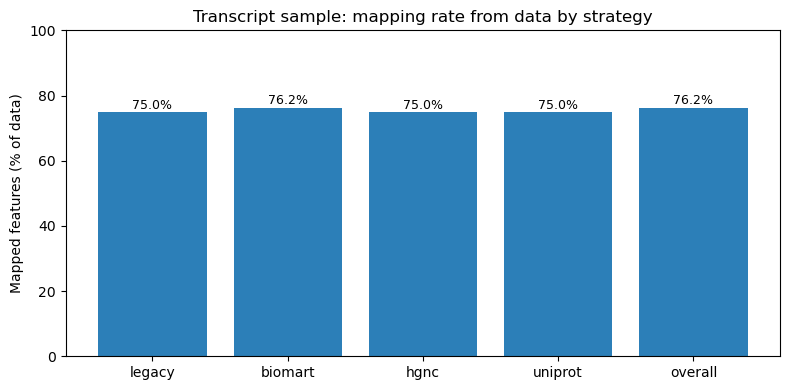

In [9]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 4))
order = ["legacy", "biomart", "hgnc", "uniprot", "overall"]
plot_df = stats.set_index("strategy").loc[order]
ax.bar(plot_df.index, plot_df["mapping_rate_from_data"] * 100, color="#2c7fb8")
ax.set_ylabel("Mapped features (% of data)")
ax.set_title("Transcript sample: mapping rate from data by strategy")
ax.set_ylim(0, 100)
for i, v in enumerate(plot_df["mapping_rate_from_data"] * 100):
    ax.text(i, v + 1, f"{v:.1f}%", ha="center", fontsize=9)
fig.tight_layout()
fig.savefig(OUT_DIR / "mapping_rate_by_strategy.png", dpi=200)
plt.show()

## 7. CLI equivalents

The same workflow from a terminal (after `pip install -e .`):

```bash
ugm-map \
  --raw-dir data/sample_omics \
  --omics "transcript.csv:transcript,protein.csv:protein" \
  --override "transcript.csv:gene" \
  --strategy optimized \
  --profile overall \
  --output-dir outputs/cli_prepared

ugm-compare \
  --csv data/sample_omics/transcript.csv \
  --node-type gene \
  --out-dir outputs/cli_compare \
  --dataset sample_transcript
```

## 8. Using your own cohort

1. Put wide CSVs in a folder (`sample_id` / `diagnosis` columns are ignored).
2. Call `prepare_multi_cohort_raw_with_strategy` with your `omics_files` map.
3. Copy outputs into Multi-Omics AD as:
   - `raw/{cohort}/feature_map.csv`
   - `raw/{cohort}/measured_entities.json`
4. Keep the **same** universal graph version as the rest of the team.

In [10]:
print("Tutorial outputs so far:")
for p in sorted(OUT_DIR.rglob("*")):
    if p.is_file():
        print(f"  {p.relative_to(PKG_ROOT)}  ({p.stat().st_size:,} bytes)")


Tutorial outputs so far:
  outputs/notebook_tutorial/coverage_by_strategy.csv  (1,069 bytes)
  outputs/notebook_tutorial/demo_feature_map.csv  (3,209 bytes)
  outputs/notebook_tutorial/mapping_rate_by_strategy.png  (54,032 bytes)
  outputs/notebook_tutorial/prepared_cohort/feature_map.csv  (6,089 bytes)
  outputs/notebook_tutorial/prepared_cohort/feature_map_detailed.csv  (14,328 bytes)
  outputs/notebook_tutorial/prepared_cohort/measured_entities.json  (1,940 bytes)
  outputs/notebook_tutorial/transcript_map_biomart.csv  (7,824 bytes)
  outputs/notebook_tutorial/transcript_map_hgnc.csv  (7,693 bytes)
  outputs/notebook_tutorial/transcript_map_legacy.csv  (7,565 bytes)
  outputs/notebook_tutorial/transcript_map_overall.csv  (7,912 bytes)
  outputs/notebook_tutorial/transcript_map_uniprot.csv  (7,665 bytes)
  outputs/notebook_tutorial/user_mapping/user_feature_map.csv  (3,164 bytes)
  outputs/notebook_tutorial/user_mapping/user_mapped_entity_ids.txt  (35 bytes)
  outputs/notebook_tutori

## 9. Map your own features (list or text file)

Use this section as a **drop-in mapper** for any feature IDs you care about.

**Inputs (choose one):**
1. A Python list in the next cell (`MY_FEATURES`)
2. A plain text file — one ID per line (`FEATURE_FILE`). Lines starting with `#` are ignored.

**What runs:**
- **Legacy** mapping (exact graph ID / suffix match)
- Your selected method (`PROFILE`: overall / biomart / hgnc / uniprot)

**Rates reported for both methods:**
- **From data** = mapped features ÷ input features
- **To network** = unique graph entities hit ÷ graph nodes of that type

**Outputs** (under `outputs/notebook_tutorial/user_mapping/`):
- `user_feature_map_legacy.csv` / `user_feature_map_<profile>.csv`
- `user_mapped_features_<method>.txt` — input IDs that hit the graph
- `user_mapped_entity_ids_<method>.txt` — unique graph entity IDs
- `user_unmapped_features_<method>.txt`
- `user_mapping_rates.csv` — side-by-side rate table

Requires Sections 0–2 to have been run (graph + mapper tables loaded).


In [11]:
# ---------------------------------------------------------------------------
# EDIT THESE
# ---------------------------------------------------------------------------

# Target graph node type: "gene", "transcript", or "protein"
NODE_TYPE = "gene"

# Selected mapping method (always compared against legacy):
#   "overall" (recommended), "biomart", "hgnc", "uniprot"
PROFILE = "overall"

# Option A — paste feature IDs here (leave empty to use the text file instead)
MY_FEATURES: list[str] = [
    # "ENSG00000141510",
    # "TP53",
    # "P04637",
]

# Option B — path to a text file (one feature ID per line)
# Default points at the packaged example; change to your own file.
FEATURE_FILE = PKG_ROOT / "data" / "sample_omics" / "example_features.txt"
# FEATURE_FILE = Path("/path/to/your_features.txt")

# Prefer the list when non-empty; otherwise load FEATURE_FILE
USE_LIST_IF_NONEMPTY = True


In [12]:
from universal_graph_mapper.mapping.stats import compute_dataset_omics_stats


def load_feature_ids_from_text(path: Path) -> list[str]:
    """Load feature IDs from a text file (one per line; # comments allowed)."""
    path = Path(path)
    if not path.is_file():
        raise FileNotFoundError(f"Feature file not found: {path}")
    ids: list[str] = []
    for line in path.read_text().splitlines():
        line = line.strip()
        if not line or line.startswith("#"):
            continue
        for tok in line.replace(";", ",").replace(chr(9), ",").split(","):
            tok = tok.strip()
            if tok and not tok.startswith("#"):
                ids.append(tok)
    seen: set[str] = set()
    out: list[str] = []
    for x in ids:
        if x not in seen:
            seen.add(x)
            out.append(x)
    return out


def map_feature_list(
    features: list[str],
    *,
    node_type: str = "gene",
    profile: str = "overall",
) -> pd.DataFrame:
    """Map feature IDs onto the universal graph. profile='legacy' for exact match only."""
    if not features:
        raise ValueError("No features provided. Fill MY_FEATURES or point FEATURE_FILE at a text file.")

    entities_by_type = {
        "gene": gene_entities,
        "transcript": tx_entities,
        "protein": prot_entities,
    }
    if node_type not in entities_by_type:
        raise ValueError(f"node_type must be one of {sorted(entities_by_type)}; got {node_type!r}")

    graph_entities = entities_by_type[node_type]
    if profile == "legacy":
        strategy = MappingStrategy.LEGACY
        resolver = OptimizedResolver(sources=[], strategy_label="legacy")
    else:
        strategy = MappingStrategy.OPTIMIZED
        resolver = OptimizedResolver(
            sources=make_sources_for_profile(profile),
            strategy_label=profile,
        )

    rows = run_legacy_then_optimize(
        features,
        node_type=node_type,
        graph_entities=graph_entities,
        omics_file="user_features",
        resolver=resolver,
        strategy=strategy,
    )
    return feature_rows_to_frame(rows)


def write_mapping_side_outputs(frame: pd.DataFrame, out_dir: Path, label: str) -> dict:
    """Write mapped / unmapped ID lists for one method; return summary counts."""
    mapped = frame[frame["in_graph"].astype(bool)].copy()
    unmapped = frame[~frame["in_graph"].astype(bool)].copy()

    (out_dir / f"user_mapped_features_{label}.txt").write_text(
        "\n".join(mapped["feature_col"].astype(str).tolist()) + ("\n" if len(mapped) else "")
    )
    (out_dir / f"user_unmapped_features_{label}.txt").write_text(
        "\n".join(unmapped["feature_col"].astype(str).tolist()) + ("\n" if len(unmapped) else "")
    )

    entity_ids: list[str] = []
    seen_e: set[str] = set()
    for col in ("entity_ids", "entity_id"):
        if col not in mapped.columns:
            continue
        for cell in mapped[col].fillna("").astype(str):
            for eid in str(cell).split("|"):
                eid = eid.strip()
                if eid and eid not in seen_e:
                    seen_e.add(eid)
                    entity_ids.append(eid)
    (out_dir / f"user_mapped_entity_ids_{label}.txt").write_text(
        "\n".join(entity_ids) + ("\n" if entity_ids else "")
    )
    return {
        "n_mapped_features": int(len(mapped)),
        "n_unmapped_features": int(len(unmapped)),
        "n_unique_entities": len(entity_ids),
    }


# Resolve input features
if USE_LIST_IF_NONEMPTY and MY_FEATURES:
    user_features = list(MY_FEATURES)
    source_desc = f"Python list ({len(user_features)} IDs)"
else:
    user_features = load_feature_ids_from_text(FEATURE_FILE)
    source_desc = f"file {Path(FEATURE_FILE).resolve()} ({len(user_features)} IDs)"

print("Input:", source_desc)
print("Node type:", NODE_TYPE)
print("Selected method:", PROFILE, "(always compared to legacy)")
print("First IDs:", user_features[:10])


Input: file /home/bioinformatics/Desktop/universal_graph_feature_mapper/data/sample_omics/example_features.txt (9 IDs)
Node type: gene
Selected method: overall (always compared to legacy)
First IDs: ['ENSG00000141510', 'ENSG00000171862', 'TP53', 'APOE', 'P04637', 'Q07973', 'Q07973_transcript', 'P05067_protein', 'NOT_A_REAL_FEATURE_XYZ']


In [13]:
if PROFILE == "legacy":
    raise ValueError(
        "PROFILE is already 'legacy'. Set PROFILE to 'overall', 'biomart', 'hgnc', or 'uniprot' "
        "so this section can compare legacy vs the selected method."
    )

USER_OUT = OUT_DIR / "user_mapping"
USER_OUT.mkdir(parents=True, exist_ok=True)

entities_by_type = {
    "gene": gene_entities,
    "transcript": tx_entities,
    "protein": prot_entities,
}
n_graph_nodes = len(entities_by_type[NODE_TYPE])

# --- Run BOTH methods ---
methods = ["legacy", PROFILE]
frames: dict[str, pd.DataFrame] = {}
for method in methods:
    frames[method] = map_feature_list(user_features, node_type=NODE_TYPE, profile=method)
    frames[method].to_csv(USER_OUT / f"user_feature_map_{method}.csv", index=False)
    write_mapping_side_outputs(frames[method], USER_OUT, method)

# --- Rates: from data + to network ---
rate_rows = []
for method, frame in frames.items():
    stats = compute_dataset_omics_stats(
        frame,
        dataset="user_features",
        strategy_label=method,
        network_nodes_by_omics_file={"user_features": n_graph_nodes},
    )
    rate_rows.append(stats)

rates = pd.concat(rate_rows, ignore_index=True)
rates.to_csv(USER_OUT / "user_mapping_rates.csv", index=False)

# Pretty printed comparison
rate_view = rates[
    [
        "strategy",
        "n_data_features",
        "n_mapped_features",
        "n_intersection_nodes",
        "n_graph_nodes",
        "mapping_rate_from_data",
        "mapping_rate_to_network",
    ]
].copy()
rate_view["mapping_rate_from_data_pct"] = (rate_view["mapping_rate_from_data"] * 100).round(2)
rate_view["mapping_rate_to_network_pct"] = (rate_view["mapping_rate_to_network"] * 100).round(2)

print("=" * 72)
print(f"MAPPING RATES  |  node_type={NODE_TYPE}  |  n_input={len(user_features)}  |  n_graph_nodes={n_graph_nodes}")
print("=" * 72)
for _, row in rate_view.iterrows():
    print(
        f"  {row['strategy']:<10s}  "
        f"from data: {row['n_mapped_features']}/{row['n_data_features']} "
        f"= {row['mapping_rate_from_data_pct']:.2f}%   |   "
        f"to network: {row['n_intersection_nodes']}/{row['n_graph_nodes']} "
        f"= {row['mapping_rate_to_network_pct']:.2f}%"
    )

# Absolute gain of selected method over legacy
leg = rate_view.set_index("strategy").loc["legacy"]
sel = rate_view.set_index("strategy").loc[PROFILE]
print("-" * 72)
print(
    f"  Gain ({PROFILE} − legacy):  "
    f"from data {sel['mapping_rate_from_data_pct'] - leg['mapping_rate_from_data_pct']:+.2f} pp   |   "
    f"to network {sel['mapping_rate_to_network_pct'] - leg['mapping_rate_to_network_pct']:+.2f} pp"
)
print("=" * 72)

display(rate_view)

# Keep selected-method frame as the primary detailed table
user_map = frames[PROFILE]
mapped = user_map[user_map["in_graph"].astype(bool)].copy()
unmapped = user_map[~user_map["in_graph"].astype(bool)].copy()
legacy_map = frames["legacy"]

display_cols = [
    "feature_col", "entity_id", "in_graph", "strategy",
    "detected_type", "mapping_path", "status", "failure_reason",
]
print(f"\nDetailed map — selected method ({PROFILE}):")
display(user_map[display_cols])


MAPPING RATES  |  node_type=gene  |  n_input=9  |  n_graph_nodes=6006
  legacy      from data: 3/9 = 33.33%   |   to network: 2/6006 = 0.03%
  overall     from data: 8/9 = 88.89%   |   to network: 5/6006 = 0.08%
------------------------------------------------------------------------
  Gain (overall − legacy):  from data +55.56 pp   |   to network +0.05 pp


,strategy,n_data_features,n_mapped_features,n_intersection_nodes,n_graph_nodes,mapping_rate_from_data,mapping_rate_to_network,mapping_rate_from_data_pct,mapping_rate_to_network_pct
0,legacy,9,3,2,6006,0.333333,0.000333,33.33,0.03
1,overall,9,8,5,6006,0.888889,0.000833,88.89,0.08



Detailed map — selected method (overall):


,feature_col,entity_id,in_graph,strategy,detected_type,mapping_path,status,failure_reason
0,ENSG00000141510,P04637,True,overall,ensembl_gene,Ensembl Gene → UniProt,success,
1,ENSG00000171862,P60484,True,overall,ensembl_gene,Ensembl Gene → UniProt,success,
2,TP53,P04637,True,overall,gene_symbol,Gene Symbol → UniProt,success,
3,APOE,P02649,True,overall,gene_symbol,Gene Symbol → UniProt,success,
4,P04637,P04637,True,legacy,uniprot,Legacy mapper,success,
5,Q07973,Q07973,True,legacy,uniprot,Legacy mapper,success,
6,Q07973_transcript,Q07973,True,legacy,uniprot,Legacy mapper,success,
7,P05067_protein,P05067,True,overall,uniprot,Already UniProt,success,
8,NOT_A_REAL_FEATURE_XYZ,,False,overall,gene_symbol,Not mapped,unmapped,missing_mapping


In [14]:
print(f"=== MAPPED ({PROFILE}) ===")
display(mapped[display_cols] if len(mapped) else pd.DataFrame({"note": ["(none)"]}))
print(f"=== UNMAPPED ({PROFILE}) ===")
display(unmapped[display_cols] if len(unmapped) else pd.DataFrame({"note": ["(none)"]}))

# Side-by-side: which features legacy missed but selected recovered
leg_hit = set(legacy_map.loc[legacy_map["in_graph"].astype(bool), "feature_col"].astype(str))
sel_hit = set(user_map.loc[user_map["in_graph"].astype(bool), "feature_col"].astype(str))
recovered = sorted(sel_hit - leg_hit)
lost = sorted(leg_hit - sel_hit)  # should be empty (legacy-first invariant)
print(f"\nRecovered by {PROFILE} (legacy miss → selected hit): {len(recovered)}")
if recovered:
    display(user_map[user_map["feature_col"].isin(recovered)][display_cols])
if lost:
    print(f"WARNING: {len(lost)} legacy hits missing from selected (unexpected):", lost[:20])

print(f"\nWrote rates + maps to: {USER_OUT.relative_to(PKG_ROOT)}/")
for f in sorted(USER_OUT.iterdir()):
    print(f"  {f.name}")
print("\nDone. Edit MY_FEATURES or FEATURE_FILE above and re-run Section 9.")


=== MAPPED (overall) ===


,feature_col,entity_id,in_graph,strategy,detected_type,mapping_path,status,failure_reason
0,ENSG00000141510,P04637,True,overall,ensembl_gene,Ensembl Gene → UniProt,success,
1,ENSG00000171862,P60484,True,overall,ensembl_gene,Ensembl Gene → UniProt,success,
2,TP53,P04637,True,overall,gene_symbol,Gene Symbol → UniProt,success,
3,APOE,P02649,True,overall,gene_symbol,Gene Symbol → UniProt,success,
4,P04637,P04637,True,legacy,uniprot,Legacy mapper,success,
5,Q07973,Q07973,True,legacy,uniprot,Legacy mapper,success,
6,Q07973_transcript,Q07973,True,legacy,uniprot,Legacy mapper,success,
7,P05067_protein,P05067,True,overall,uniprot,Already UniProt,success,


=== UNMAPPED (overall) ===


,feature_col,entity_id,in_graph,strategy,detected_type,mapping_path,status,failure_reason
8,NOT_A_REAL_FEATURE_XYZ,,False,overall,gene_symbol,Not mapped,unmapped,missing_mapping



Recovered by overall (legacy miss → selected hit): 5


,feature_col,entity_id,in_graph,strategy,detected_type,mapping_path,status,failure_reason
0,ENSG00000141510,P04637,True,overall,ensembl_gene,Ensembl Gene → UniProt,success,
1,ENSG00000171862,P60484,True,overall,ensembl_gene,Ensembl Gene → UniProt,success,
2,TP53,P04637,True,overall,gene_symbol,Gene Symbol → UniProt,success,
3,APOE,P02649,True,overall,gene_symbol,Gene Symbol → UniProt,success,
7,P05067_protein,P05067,True,overall,uniprot,Already UniProt,success,



Wrote rates + maps to: outputs/notebook_tutorial/user_mapping/
  user_feature_map.csv
  user_feature_map_legacy.csv
  user_feature_map_overall.csv
  user_mapped_entity_ids.txt
  user_mapped_entity_ids_legacy.txt
  user_mapped_entity_ids_overall.txt
  user_mapped_features.txt
  user_mapped_features_legacy.txt
  user_mapped_features_overall.txt
  user_mapping_rates.csv
  user_unmapped_features.txt
  user_unmapped_features_legacy.txt
  user_unmapped_features_overall.txt

Done. Edit MY_FEATURES or FEATURE_FILE above and re-run Section 9.
